In [14]:
import numpy as np

def get_branin(x1, x2):
    # Branin function implementation
    a = 1
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6
    s = 10
    t = 1 / (8 * np.pi)
    
    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s

print(get_branin(0, 0))


55.602112642270264


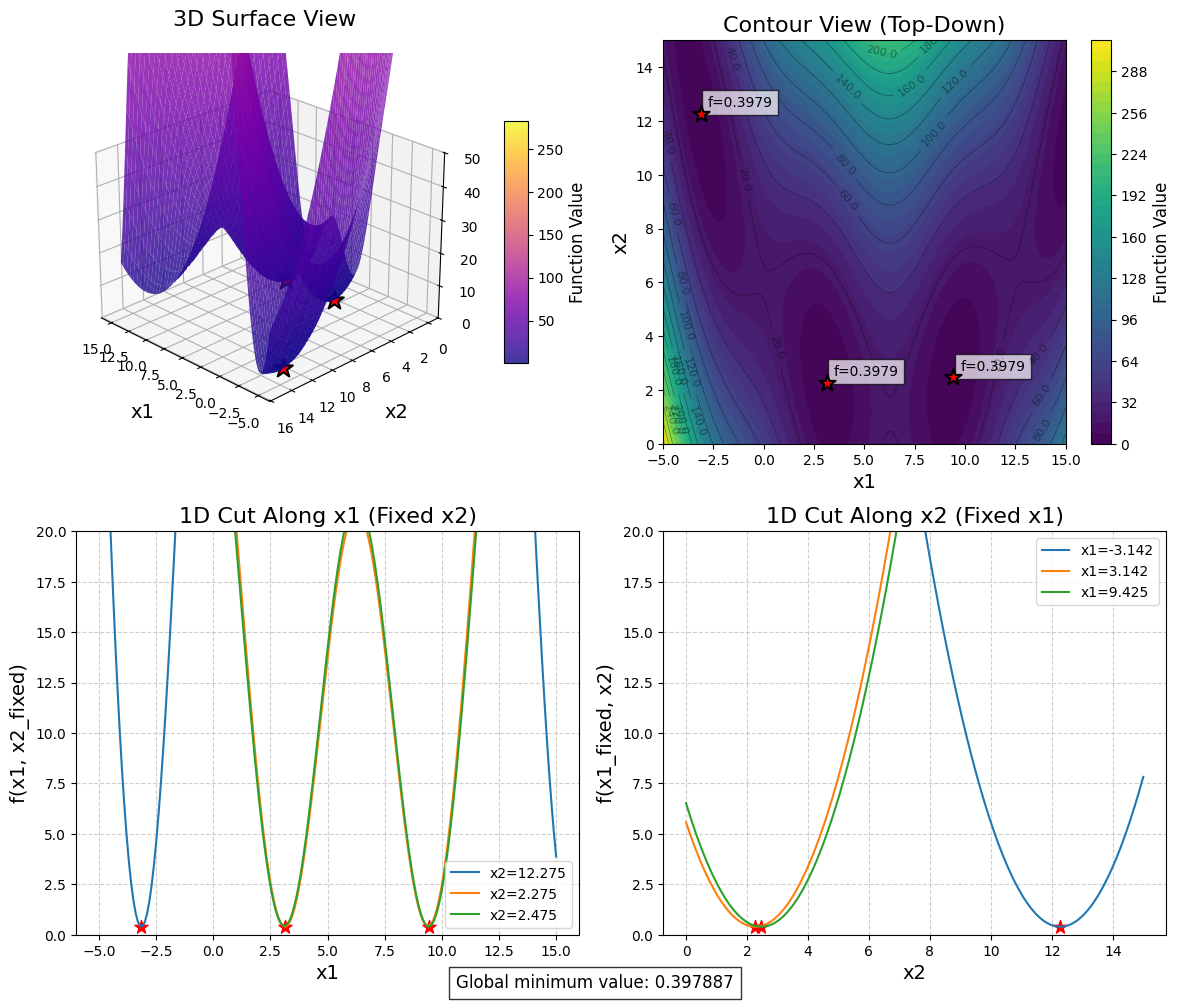

In [2]:
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Create a grid of points for visualization
x1_range = np.linspace(-5, 15, 200)  # Increased resolution
x2_range = np.linspace(0, 15, 200)   # Increased resolution
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Calculate Branin function values for each point in the grid
z_grid = np.zeros_like(x1_grid)
for i in range(len(x1_range)):
    for j in range(len(x2_range)):
        z_grid[j, i] = get_branin(x1_grid[j, i], x2_grid[j, i])

# Create figure with larger size for 4 subplots
fig = plt.figure(figsize=(12, 10))

# Create four subplots - 3D surface, 2D contour, and two 1D cuts
ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)  # 1D cut along x1
ax4 = fig.add_subplot(224)  # 1D cut along x2

# Plot the surface with improved visibility
surf = ax1.plot_surface(x1_grid, x2_grid, z_grid, cmap=cm.plasma, 
                      linewidth=0, antialiased=True, alpha=0.8)

# Add color bar
cbar1 = fig.colorbar(surf, ax=ax1, shrink=0.6, aspect=10, pad=0.1)
cbar1.set_label('Function Value', fontsize=12)

# Set z-axis limit to focus on the lower part of the function
ax1.set_zlim(0, 50)

# Add labels and title
ax1.set_xlabel('x1', fontsize=14, labelpad=10)
ax1.set_ylabel('x2', fontsize=14, labelpad=10)
ax1.set_zlabel('f(x1, x2)', fontsize=14, labelpad=10)
ax1.set_title('3D Surface View', fontsize=16, pad=20)

# Adjust view angle for better visibility
ax1.view_init(elev=25, azim=135)  # Changed angle for better perspective

# Add grid lines
ax1.grid(True, linestyle='--', alpha=0.6)

# Create contour plot on the second subplot
contour = ax2.contourf(x1_grid, x2_grid, z_grid, 50, cmap=cm.viridis)
contour_lines = ax2.contour(x1_grid, x2_grid, z_grid, 15, colors='black', alpha=0.4, linewidths=0.5)
ax2.clabel(contour_lines, inline=True, fontsize=8, fmt='%.1f')
cbar2 = fig.colorbar(contour, ax=ax2)
cbar2.set_label('Function Value', fontsize=12)

# Add labels and title to contour plot
ax2.set_xlabel('x1', fontsize=14)
ax2.set_ylabel('x2', fontsize=14)
ax2.set_title('Contour View (Top-Down)', fontsize=16)

# Highlight the known global minima on both plots
minima = [(-np.pi, 12.275), (np.pi, 2.275), (9.42478, 2.475)]
for minimum in minima:
    x1_min, x2_min = minimum
    z_min = get_branin(x1_min, x2_min)
    
    # Add to 3D plot
    ax1.scatter([x1_min], [x2_min], [z_min], color='red', s=200, marker='*', 
               edgecolor='black', linewidth=1.5, zorder=10)
    
    # Add to contour plot
    ax2.scatter(x1_min, x2_min, color='red', s=150, marker='*', 
               edgecolor='black', linewidth=1.5, zorder=10)
    ax2.annotate(f'f={z_min:.4f}', (x1_min, x2_min), xytext=(5, 5), 
                textcoords='offset points', fontsize=10, 
                bbox=dict(facecolor='white', alpha=0.7))

# 1D cut along x1 (fixing x2 at optimal values)
for minimum in minima:
    x1_min, x2_min = minimum
    x1_cut = x1_range
    y_cut = [get_branin(x, x2_min) for x in x1_cut]
    ax3.plot(x1_cut, y_cut, label=f'x2={x2_min:.3f}')
    ax3.scatter(x1_min, get_branin(x1_min, x2_min), color='red', s=100, marker='*')

ax3.set_xlabel('x1', fontsize=14)
ax3.set_ylabel('f(x1, x2_fixed)', fontsize=14)
ax3.set_title('1D Cut Along x1 (Fixed x2)', fontsize=16)
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend()
ax3.set_ylim(0, 20)  # Focus on the lower part of the function

# 1D cut along x2 (fixing x1 at optimal values)
for minimum in minima:
    x1_min, x2_min = minimum
    x2_cut = x2_range
    y_cut = [get_branin(x1_min, x) for x in x2_cut]
    ax4.plot(x2_cut, y_cut, label=f'x1={x1_min:.3f}')
    ax4.scatter(x2_min, get_branin(x1_min, x2_min), color='red', s=100, marker='*')

ax4.set_xlabel('x2', fontsize=14)
ax4.set_ylabel('f(x1_fixed, x2)', fontsize=14)
ax4.set_title('1D Cut Along x2 (Fixed x1)', fontsize=16)
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.legend()
ax4.set_ylim(0, 20)  # Focus on the lower part of the function

# Add a note about the global minimum value
min_val = 0.397887
plt.figtext(0.5, 0.01, f"Global minimum value: {min_val:.6f}", 
            ha="center", fontsize=12, bbox={"facecolor":"white", "alpha":0.8, "pad":5})

plt.tight_layout()
plt.show()


In [15]:
import optuna
import time
from datetime import datetime

def objective(trial):
    x1 = trial.suggest_float("x1", -15, 15)
    x2 = trial.suggest_float("x2", -15, 15)
    
    return get_branin(x1, x2)

In [16]:
def print_results(results):
    print("Best trial:")
    print("  Value: ", results["best_value"])
    print("  Params: ")
    for key, value in results["best_params"].items():
        print(f"    {key}: {value}")
    print(f"Time elapsed: {results['time_elapsed']:.2f} seconds")


In [17]:
def run_grid_search(verbose=True):
    # Define the grid search space with more points to get 1000 trials
    # 32x32 grid = 1024 points (slightly over 1000)
    if verbose:
        optuna.logging.set_verbosity(optuna.logging.WARNING)
    else:
        optuna.logging.set_verbosity(optuna.logging.INFO)

    search_space = {
        "x1": np.linspace(-15, 15, 32).tolist(),
        "x2": np.linspace(-15, 15, 32).tolist()
    }

    # Save results in a dict
    grid_results = {
        "time_elapsed": 0,
        "best_value": None,
        "best_params": None,
        "trials": []
    }

    # Callback to track trials
    def track_trial(study, trial):
        grid_results["trials"].append({
            "number": trial.number,
            "value": trial.value,
            "params": trial.params.copy(),
            "timestamp": datetime.now().isoformat(),
            "state": trial.state
        })
        grid_results["best_value"] = study.best_trial.value
        grid_results["best_params"] = study.best_trial.params.copy()

    # Create study with GridSampler
    if verbose:
        study = optuna.create_study(sampler=optuna.samplers.GridSampler(search_space))
    else:
        study = optuna.create_study(sampler=optuna.samplers.GridSampler(search_space))

    # Track time and results
    start_time = time.time()
    study.optimize(objective, callbacks=[track_trial])
    end_time = time.time()
    grid_results["time_elapsed"] = end_time - start_time

    return grid_results


In [18]:
def run_random_search(verbose=True):
    if verbose:
        optuna.logging.set_verbosity(optuna.logging.WARNING)
    else:
        optuna.logging.set_verbosity(optuna.logging.INFO)

    # Save results in a dict
    random_results = {
        "time_elapsed": 0,
        "best_value": None,
        "best_params": None,
        "trials": []
    }

    # Callback to track trials
    def track_random_trial(study, trial):
        random_results["trials"].append({
            "number": trial.number,
            "value": trial.value,
            "params": trial.params.copy(),
            "timestamp": datetime.now().isoformat(),
            "state": trial.state
        })
        random_results["best_value"] = study.best_trial.value
        random_results["best_params"] = study.best_trial.params.copy()

    # Create study with RandomSampler
    study = optuna.create_study(sampler=optuna.samplers.RandomSampler())

    # Track time and results
    start_time = time.time()
    study.optimize(objective, n_trials=1000, callbacks=[track_random_trial])
    end_time = time.time()
    random_results["time_elapsed"] = end_time - start_time

    return random_results


In [19]:
def run_tpe_search(verbose=True):
    if verbose:
        optuna.logging.set_verbosity(optuna.logging.WARNING)
    else:
        optuna.logging.set_verbosity(optuna.logging.INFO)

    # Save results in a dict
    tpe_results = {
        "time_elapsed": 0,
        "best_value": None,
        "best_params": None,
        "trials": []
    }

    # Callback to track trials
    def track_tpe_trial(study, trial):
        tpe_results["trials"].append({
            "number": trial.number,
            "value": trial.value,
            "params": trial.params.copy(),
            "timestamp": datetime.now().isoformat(),
            "state": trial.state
        })
        tpe_results["best_value"] = study.best_trial.value
        tpe_results["best_params"] = study.best_trial.params.copy()

    # Create study with TPESampler
    study = optuna.create_study(sampler=optuna.samplers.TPESampler())

    # Track time and results
    start_time = time.time()
    study.optimize(objective, n_trials=1000, callbacks=[track_tpe_trial])
    end_time = time.time()
    tpe_results["time_elapsed"] = end_time - start_time

    return tpe_results


In [20]:
def run_gp_search(verbose=True):
    if verbose:
        optuna.logging.set_verbosity(optuna.logging.WARNING)
    else:
        optuna.logging.set_verbosity(optuna.logging.INFO)

    # Save results in a dict
    gp_results = {
        "time_elapsed": 0,
        "best_value": None,
        "best_params": None,
        "trials": []
    }

    # Callback to track trials
    def track_gp_trial(study, trial):
        gp_results["trials"].append({
            "number": trial.number,
            "value": trial.value,
            "params": trial.params.copy(),
            "timestamp": datetime.now().isoformat(),
            "state": trial.state
        })
        gp_results["best_value"] = study.best_trial.value
        gp_results["best_params"] = study.best_trial.params.copy()

    # Create study with GPSampler
    study = optuna.create_study(sampler=optuna.samplers.GPSampler())

    # Track time and results
    start_time = time.time()
    study.optimize(objective, n_trials=200, callbacks=[track_gp_trial]) #usually converges with 200 trials
    end_time = time.time()
    gp_results["time_elapsed"] = end_time - start_time

    return gp_results


In [21]:
def run_cmaes_search(verbose=True):
    if verbose:
        optuna.logging.set_verbosity(optuna.logging.WARNING)
    else:
        optuna.logging.set_verbosity(optuna.logging.INFO)


    # Save results in a dict
    cmaes_results = {
        "time_elapsed": 0,
        "best_value": None,
        "best_params": None,
        "trials": []
    }

    # Callback to track trials
    def track_cmaes_trial(study, trial):
        cmaes_results["trials"].append({
            "number": trial.number,
            "value": trial.value,
            "params": trial.params.copy(),
            "timestamp": datetime.now().isoformat(),
            "state": trial.state
        })
        cmaes_results["best_value"] = study.best_trial.value
        cmaes_results["best_params"] = study.best_trial.params.copy()

    # Create study with CmaEsSampler
    study = optuna.create_study(sampler=optuna.samplers.CmaEsSampler())

    # Track time and results
    start_time = time.time()
    study.optimize(objective, n_trials=1000, callbacks=[track_cmaes_trial])
    end_time = time.time()
    cmaes_results["time_elapsed"] = end_time - start_time

    return cmaes_results

In [22]:
import time
import keras_tuner
from keras_tuner.tuners import Hyperband
from keras_tuner import Objective

def run_hyperband_search(verbose=False):
    hyperband_results = {
        "time_elapsed": 0,
        "best_value": None,
        "best_params": None,
        "trials": []
    }

    # Define hyperparameters
    def build_model(hp):
        # Define the hyperparameters for the search space
        hp.Float('x1', min_value=-15.0, max_value=15.0)
        hp.Float('x2', min_value=-15.0, max_value=15.0)
        # Return a dummy model
        return "dummy"

    # Custom Hyperband wrapper
    class CustomHyperband(Hyperband):
        def run_trial(self, trial, *args, **kwargs):
            # Convert hp to dictionary
            hp_dict = {
                'x1': trial.hyperparameters.get('x1'),
                'x2': trial.hyperparameters.get('x2')
            }
            
            # Get the objective function value
            result = get_branin(hp_dict['x1'], hp_dict['x2'])

            # Log trial
            hyperband_results["trials"].append({
                "number": trial.trial_id,
                "value": result,
                "params": hp_dict.copy(),
                "timestamp": datetime.now().isoformat(),
                "state": "COMPLETE"
            })

            # Update best if needed
            if hyperband_results["best_value"] is None or result < hyperband_results["best_value"]:
                hyperband_results["best_value"] = result
                hyperband_results["best_params"] = hp_dict.copy()

            return result

    # Instantiate and run the tuner
    tuner = CustomHyperband(
        hypermodel=build_model,
        objective=Objective("score", direction="min"),
        factor=3,
        max_epochs=30,
        hyperband_iterations=11,  # Default is 1, controls how many times to run the full algorithm
        directory="hyperband_dir",
        project_name=f"custom_obj_{int(time.time())}",  # Add timestamp to make unique
    )

    # Time tracking
    start_time = time.time()
    tuner.search()  # No need to pass epochs or hyperband_iterations here
    end_time = time.time()
    hyperband_results["time_elapsed"] = end_time - start_time

    return hyperband_results


Trial 990 Complete [00h 00m 00s]
score: 610.0580865518458

Best score So Far: 0.5260199220301374
Total elapsed time: 00h 00m 37s


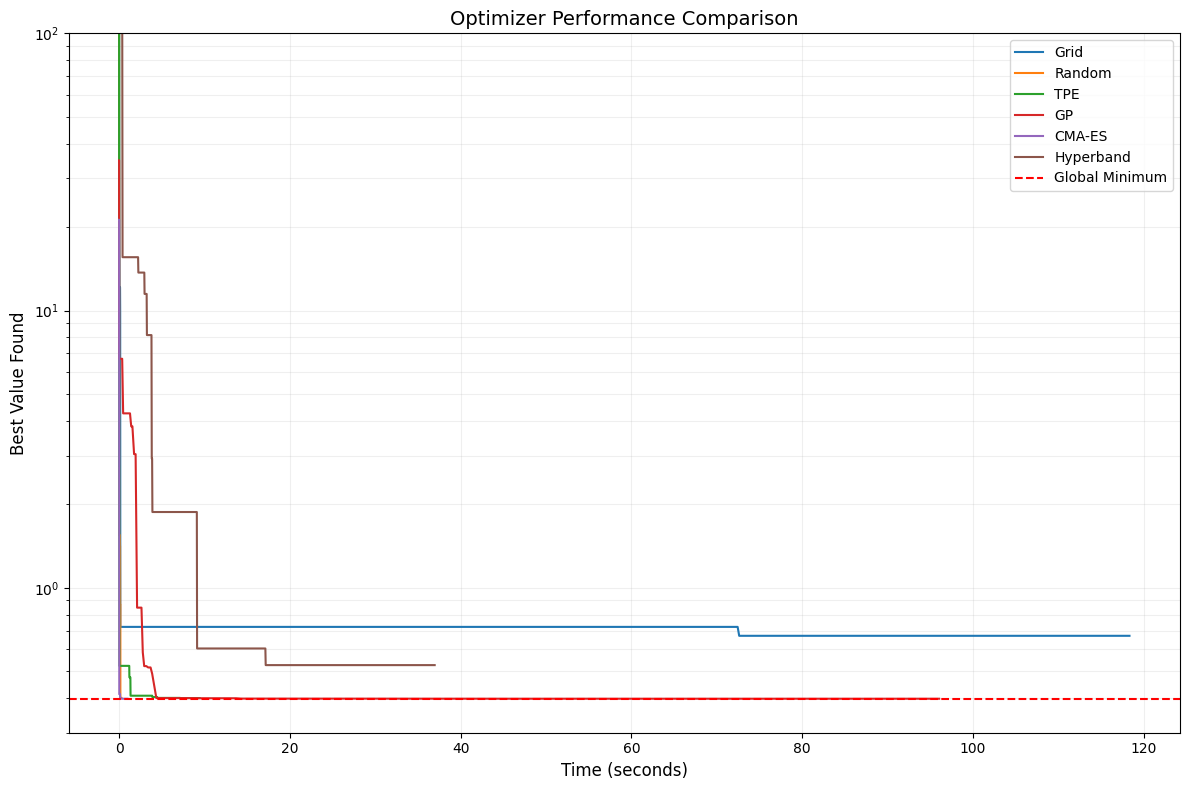


Final best values found:
Grid: 0.670999
Random: 0.400469
TPE: 0.400065
GP: 0.397887
CMA-ES: 0.397887
Hyperband: 0.526020


In [104]:
import matplotlib.pyplot as plt
import numpy as np
#NOTE: This is basically a random search, as this algorithm is designed for early stopping
results = {}
for function in [run_grid_search, run_random_search, run_tpe_search, run_gp_search, run_cmaes_search, run_hyperband_search]:
    print(f'running {function.__name__}...')
    results[function.__name__] = function()

def process_results(results, name):
    # Convert timestamps to seconds from start
    start_time = datetime.fromisoformat(results['trials'][0]['timestamp'])
    times = []
    best_values = []
    current_best = float('inf')
    
    for trial in results['trials']:
        # Get time in seconds from start
        trial_time = (datetime.fromisoformat(trial['timestamp']) - start_time).total_seconds()
        
        # Skip if beyond 180 seconds
        if trial_time > 180:
            continue
            
        # Update current best
        current_best = min(current_best, trial['value'])
        
        times.append(trial_time)
        best_values.append(current_best)
    
    return times, best_values, name

# Set up the plot
plt.figure(figsize=(12, 8))

# Colors for each optimizer
colors = {
    'Grid': '#1f77b4',
    'Random': '#ff7f0e',
    'TPE': '#2ca02c',
    'GP': '#d62728',
    'CMA-ES': '#9467bd',
    'Hyperband': '#8c564b'
}

# Process and plot each optimizer's results
all_results = [
    (results['run_grid_search'], 'Grid'),
    (results['run_random_search'], 'Random'),
    (results['run_tpe_search'], 'TPE'),
    (results['run_gp_search'], 'GP'),
    (results['run_cmaes_search'], 'CMA-ES'),
    (results['run_hyperband_search'], 'Hyperband')
]

for results, name in all_results:
    times, best_values, label = process_results(results, name)
    plt.plot(times, best_values, label=label, color=colors[label])

# Add the global minimum as a horizontal line
plt.axhline(y=0.397887, color='r', linestyle='--', label='Global Minimum')

# Customize the plot
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Best Value Found', fontsize=12)
plt.title('Optimizer Performance Comparison', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Set y-axis to log scale and limit the range
plt.yscale('log')
plt.ylim(0.3, 100)  # Adjust these values based on your actual results

# Add grid
plt.grid(True, which="both", ls="-", alpha=0.2)

# Tight layout to prevent label clipping
plt.tight_layout()

plt.show()

# Print final best values
print("\nFinal best values found:")
for results, name in all_results:
    print(f"{name}: {results['best_value']:.6f}")

In [11]:
import json

def run_k_trials(k):
    from tqdm.notebook import tqdm
    
    grid_results = []
    random_results = []
    tpe_results = []
    gp_results = []
    cmaes_results = []
    hyperband_results = []
    
    for i in tqdm(range(k), desc="Running trials"):
        grid_results.append(run_grid_search())
        random_results.append(run_random_search())
        tpe_results.append(run_tpe_search())
        gp_results.append(run_gp_search())
        cmaes_results.append(run_cmaes_search())
        hyperband_results.append(run_hyperband_search())
        
    return grid_results, random_results, tpe_results, gp_results, cmaes_results, hyperband_results

k = 2
grid_results, random_results, tpe_results, gp_results, cmaes_results, hyperband_results = run_k_trials(2)
results = {
    'grid_results': grid_results,
    'random_results': random_results,
    'tpe_results': tpe_results,
    'gp_results': gp_results,
    'cmaes_results': cmaes_results,
    'hyperband_results': hyperband_results
}
with open(f'{k}_results.json', 'w') as f:
    json.dump(results, f)

Trial 990 Complete [00h 00m 00s]
score: 28.83105886679736

Best score So Far: 1.2407283936981823
Total elapsed time: 00h 00m 18s


In [28]:
from joblib import Parallel, delayed

METHODS = {
    'grid_results':      run_grid_search,
    'random_results':    run_random_search,
    'tpe_results':       run_tpe_search,
    'gp_results':        run_gp_search,
    'cmaes_results':     run_cmaes_search,
    'hyperband_results': run_hyperband_search,
}

def run_k_trials_joblib(k, n_jobs=6):
    # Prepare k runs × 6 methods
    tasks = [(name, METHODS[name]) 
             for _ in range(k)
             for name in METHODS]
    
    # Launch in parallel
    outputs = Parallel(n_jobs=n_jobs)(
        delayed(fn)() for name, fn in tasks
    )
    
    # Collect back into your dict-of-lists
    results = {name: [] for name in METHODS}
    for (name, _), out in zip(tasks, outputs):
        results[name].append(out)
    return results

# Example in your notebook:
k = 50
results = run_k_trials_joblib(k, n_jobs=6)

import json
with open(f"{k}_results.json", "w") as f:
    json.dump(results, f, indent=2)


Figure saved to average_best_value_over_time_50_trials.png


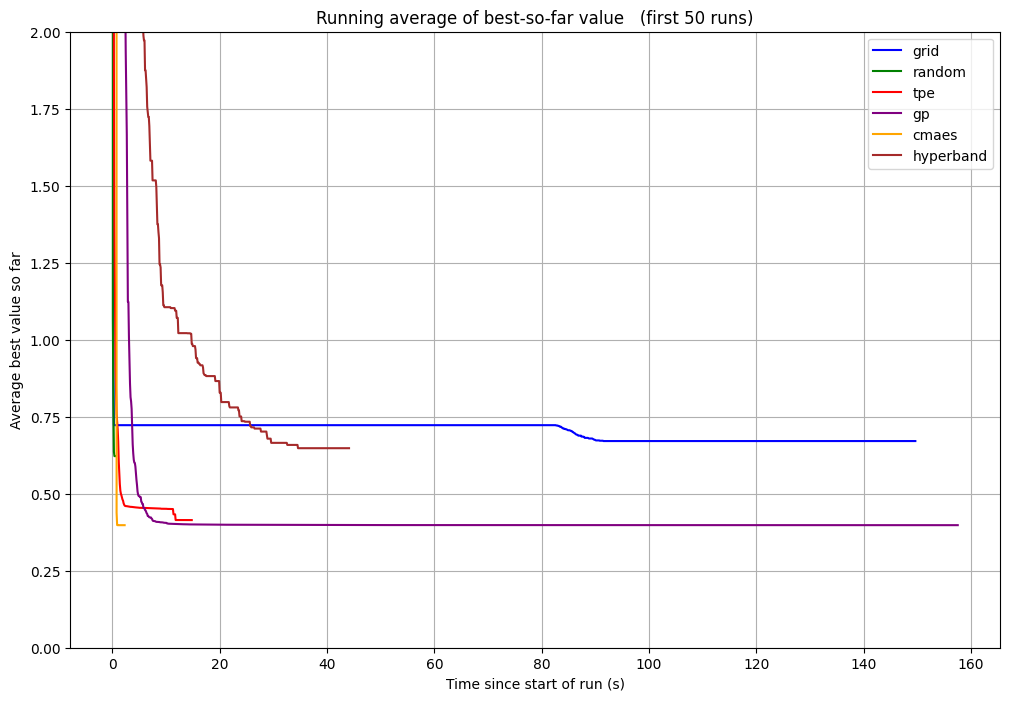

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

def plot_average_best_value_over_time(results, k, bin_size=0.1, savefig=True):
    colors = {
        'grid_results':   'blue',
        'random_results': 'green',
        'tpe_results':    'red',
        'gp_results':     'purple',
        'cmaes_results':  'orange',
        'hyperband_results': 'brown'
    }

    fig, ax = plt.subplots(figsize=(12, 8))

    for method_name, method_runs in results.items():
        per_run_series = []
        t_max = 0.0

        for run in method_runs[:k]:
            trials = run["trials"]
            t0 = datetime.fromisoformat(trials[0]["timestamp"])

            best_so_far = np.inf
            times, bests = [], []

            for t in trials:
                t_sec = (datetime.fromisoformat(t["timestamp"]) - t0).total_seconds()
                best_so_far = min(best_so_far, t["value"])
                times.append(t_sec)
                bests.append(best_so_far)

            
            s = pd.Series(bests, index=times)
            s = s.groupby(level=0).last().sort_index()

            per_run_series.append(s)
            t_max = max(t_max, s.index[-1])

        grid = np.arange(0, t_max + bin_size, bin_size)

        filled = []
        for s in per_run_series:
            s = s.reindex(sorted(set(grid).union(s.index))).sort_index()
            s = s.ffill()
            filled.append(s.reindex(grid))

        avg_best = pd.concat(filled, axis=1).mean(axis=1)

        label = method_name.replace("_results", "")
        ax.plot(grid, avg_best, label=label,
                color=colors.get(method_name, None))

    ax.set_xlabel("Time since start of run (s)")
    ax.set_ylabel("Average best value so far")
    ax.set_title(f"Running average of best-so-far value   (first {k} runs)")
    ax.legend()
    ax.grid(True)

    if savefig:
        fname = f"average_best_value_over_time_{k}_trials.png"
        plt.savefig(fname, dpi=300)
        print(f"Figure saved to {fname}")

    plt.ylim(0, 2)  # Set y-axis maximum to 40
    plt.show()



# Load the results from the JSON file
import json
with open(f'{k}_results.json', 'r') as f:
    results = json.load(f)

# Plot the average best value over time
plot_average_best_value_over_time(results, k)

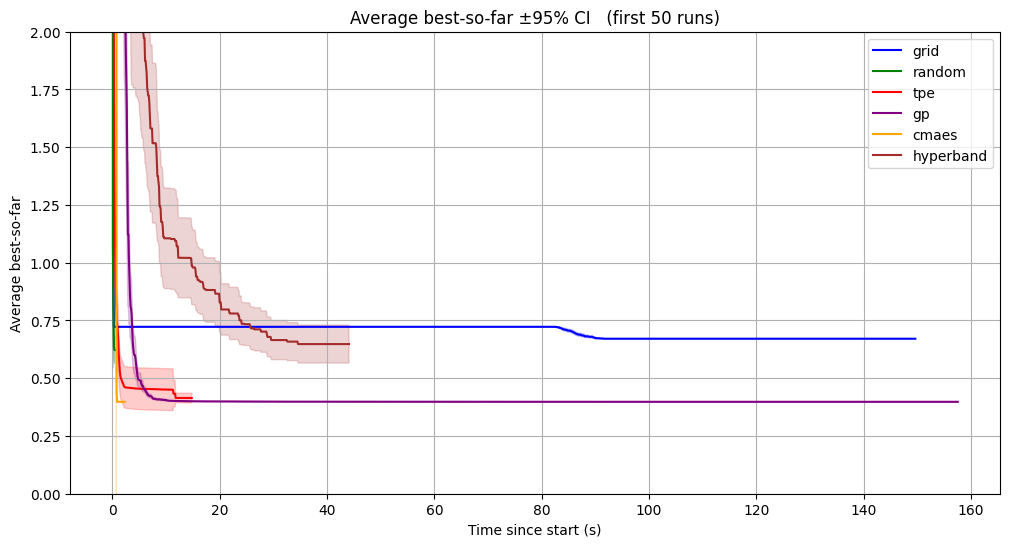

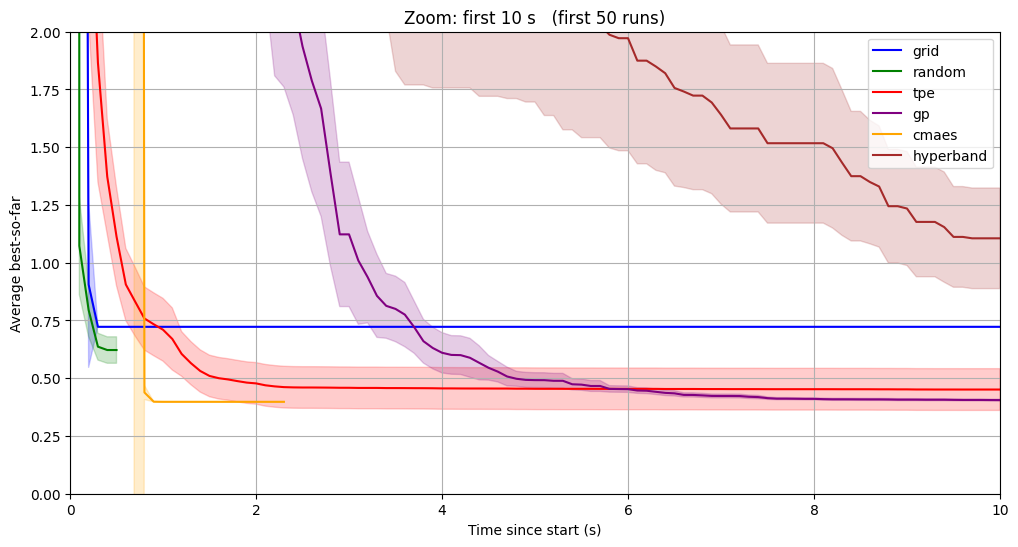

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

def plot_average_with_ci_and_zoom(results, k, bin_size=0.1, zoom_to=10, savefig=True):
    """
    results: dict of lists, same shape as before
    k: number of runs to average
    bin_size: time bin width in seconds
    zoom_to: x-axis limit for the zoomed plot (e.g. 10 sec)
    """
    colors = {
        'grid_results':     'blue',
        'random_results':   'green',
        'tpe_results':      'red',
        'gp_results':       'purple',
        'cmaes_results':    'orange',
        'hyperband_results':'brown'
    }

    # First, collect mean+ci for each method
    summary = {}
    for method_name, method_runs in results.items():
        per_run = []
        t_max = 0.0

        # Build each run’s best‐so‐far series
        for run in method_runs[:k]:
            trials = run["trials"]
            t0 = datetime.fromisoformat(trials[0]["timestamp"])

            best = np.inf
            times, vals = [], []
            for t in trials:
                sec = (datetime.fromisoformat(t["timestamp"]) - t0).total_seconds()
                best = min(best, t["value"])
                times.append(sec)
                vals.append(best)

            s = pd.Series(vals, index=times)
            s = s.groupby(level=0).last().sort_index()  # drop duplicate timestamps
            per_run.append(s)
            t_max = max(t_max, s.index[-1])

        # Align all runs onto a uniform grid
        grid = np.arange(0, t_max + bin_size, bin_size)
        aligned = []
        for s in per_run:
            s2 = s.reindex(sorted(set(grid).union(s.index))).sort_index().ffill()
            aligned.append(s2.reindex(grid))

        df = pd.concat(aligned, axis=1)  # shape = (len(grid), k)
        mean = df.mean(axis=1)
        sem  = df.std(axis=1, ddof=1) / np.sqrt(k)
        ci   = 1.96 * sem

        summary[method_name] = {
            "grid": grid,
            "mean": mean,
            "lower": mean - ci,
            "upper": mean + ci
        }

    # --- Full-range plot ---------------------------------------------
    plt.figure(figsize=(12, 6))
    for method_name, data in summary.items():
        label = method_name.replace("_results", "")
        c = colors.get(method_name)
        plt.plot(data["grid"], data["mean"], label=label, color=c)
        plt.fill_between(data["grid"],
                         data["lower"],
                         data["upper"],
                         color=c, alpha=0.2)
    plt.xlabel("Time since start (s)")
    plt.ylabel("Average best-so-far")
    plt.title(f"Average best-so-far ±95% CI   (first {k} runs)")
    plt.legend()
    plt.grid(True)
    plt.ylim(0, 2)  # Set y-axis maximum to 40
    if savefig:
        plt.savefig(f"avg_best_full_{k}.png", dpi=300)
    plt.show()

    # --- Zoomed-in plot (first zoom_to seconds) ----------------------
    plt.figure(figsize=(12, 6))
    for method_name, data in summary.items():
        mask = data["grid"] <= zoom_to
        label = method_name.replace("_results", "")
        c = colors.get(method_name)
        plt.plot(data["grid"][mask], data["mean"][mask], label=label, color=c)
        plt.fill_between(data["grid"][mask],
                         data["lower"][mask],
                         data["upper"][mask],
                         color=c, alpha=0.2)
    plt.xlabel("Time since start (s)")
    plt.xlim(0, zoom_to)
    plt.ylabel("Average best-so-far")
    plt.title(f"Zoom: first {zoom_to} s   (first {k} runs)")
    plt.legend()
    plt.ylim(0, 2)  # Set y-axis maximum to 40
    plt.grid(True)
    if savefig:
        plt.savefig(f"avg_best_zoom_{k}.png", dpi=300)
    plt.show()

plot_average_with_ci_and_zoom(results, k)